# Task 6: Cricket Match Win/Lose Prediction
### Predict match outcome based on toss, venue, and opponent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings("ignore")


In [2]:
data = {
    "toss":     ["Won","Won","Lost","Lost","Won","Won","Lost","Won","Won","Lost",
                 "Won","Lost","Won","Lost","Lost","Won","Won","Lost","Won","Lost",
                 "Won","Won","Lost","Lost","Won","Won","Lost","Won","Lost","Won"],
    "venue":    ["Home","Away","Home","Away","Home","Home","Away","Away","Home","Home",
                 "Home","Away","Away","Home","Away","Home","Home","Away","Home","Away",
                 "Away","Home","Home","Away","Home","Away","Home","Away","Home","Home"],
    "opponent": ["Weak","Strong","Weak","Strong","Weak","Strong","Weak","Weak","Strong","Weak",
                 "Weak","Strong","Weak","Strong","Strong","Weak","Strong","Weak","Weak","Strong",
                 "Weak","Weak","Strong","Weak","Weak","Strong","Weak","Strong","Weak","Weak"],
    "result":   ["Win","Win","Win","Lose","Win","Lose","Lose","Win","Lose","Win",
                 "Win","Lose","Win","Lose","Lose","Win","Lose","Lose","Win","Lose",
                 "Win","Win","Lose","Win","Win","Lose","Win","Lose","Win","Win"]
}
df = pd.DataFrame(data)
print(df.head(15))
print("\nResult Distribution:")
print(df["result"].value_counts())


    toss venue opponent result
0    Won  Home     Weak    Win
1    Won  Away   Strong    Win
2   Lost  Home     Weak    Win
3   Lost  Away   Strong   Lose
4    Won  Home     Weak    Win
5    Won  Home   Strong   Lose
6   Lost  Away     Weak   Lose
7    Won  Away     Weak    Win
8    Won  Home   Strong   Lose
9   Lost  Home     Weak    Win
10   Won  Home     Weak    Win
11  Lost  Away   Strong   Lose
12   Won  Away     Weak    Win
13  Lost  Home   Strong   Lose
14  Lost  Away   Strong   Lose

Result Distribution:
result
Win     17
Lose    13
Name: count, dtype: int64


In [3]:
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop("result", axis=1)
y = df_enc["result"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Lose","Win"]))


Accuracy: 75.0 %

Classification Report:
              precision    recall  f1-score   support

        Lose       1.00      0.33      0.50         3
         Win       0.71      1.00      0.83         5

    accuracy                           0.75         8
   macro avg       0.86      0.67      0.67         8
weighted avg       0.82      0.75      0.71         8



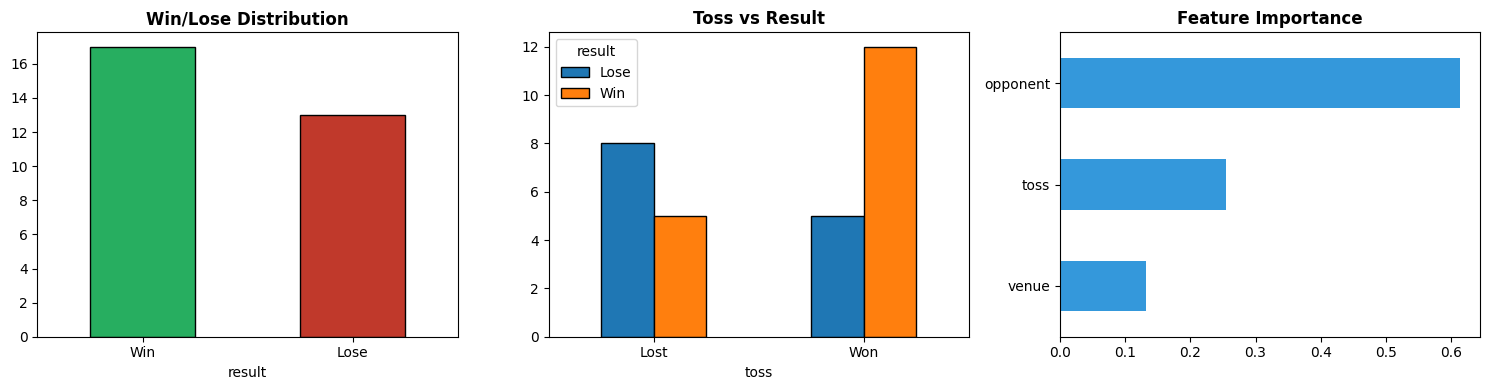

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["result"].value_counts().plot(kind="bar", ax=axes[0], color=["#27ae60","#c0392b"], edgecolor="black")
axes[0].set_title("Win/Lose Distribution", fontweight="bold"); axes[0].tick_params(rotation=0)

pd.crosstab(df["toss"], df["result"]).plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Toss vs Result", fontweight="bold"); axes[1].tick_params(rotation=0)

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind="barh", ax=axes[2], color="#3498db")
axes[2].set_title("Feature Importance", fontweight="bold")
plt.tight_layout(); plt.savefig("task6_viz.png", dpi=100); plt.show()


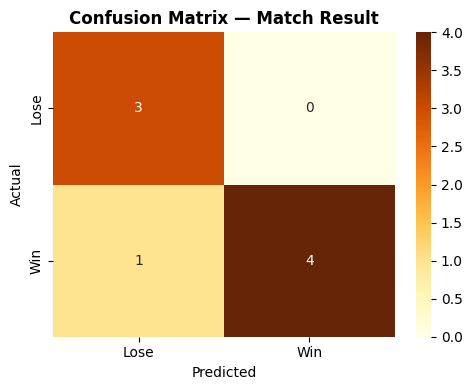

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=["Lose","Win"], yticklabels=["Lose","Win"])
plt.title("Confusion Matrix — Match Result", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("task6_cm.png", dpi=100); plt.show()
